# Wstęp do Sztucznej Inteligencji

Przed rozpoczęciem pracy z notatnikiem zmień jego nazwę zgodnie z wzorem: `NrAlbumu_Nazwisko_Imie_PoprzedniaNazwa`.

Przed wysłaniem notatnika upewnij się, że rozwiązałeś wszystkie zadania/ćwiczenia.

# Temat: Optymalizacja globalna: Problem plecakowy - Zadania
Zapoznaj się z treścią niniejszego notatnika czytając i wykonując go komórka po komórce. Wykonaj napotkane zadania/ćwiczenia.


## Problem plecakowy
Problem plecakowy to problem optymalizacji dyskretnej. W swojej najprostszej wersji może być sformułowany następująco.

Spośród `N` dostępnych przedmiotów możmy zabrać taką ich liczbę by suma ich wag nie przekraczała pewnej dopuszczalnej wartości (maksymalne obciążenie plecaka). Każdy przedmiot, oprócz wagi, ma przypisaną swoją wartość.

Które przedmioty zabrać, aby ich sumaryczna wartość była jak największa, ale ich sumaryczna waga nie przekraczała dopuszczalnej maksymalnej wagi plecaka?

Mamy zatem do czynienia z problemem optymalizacji z ograniczeniami.

Przeczytaj więcej o problemie plecakowym: https://pl.wikipedia.org/wiki/Problem_plecakowy

## Prosty generator problemu plecakowego (0-1 knapsack problem)

Generujemy listę przedmiotów, z losowymi wagami oraz wartościami z podanych przedziałów.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#%matplotlib notebook

#wmin - minimalna waga przedmiotu
#wmax - maksymalna waga przedmiotu
#vmin - minimalna wartość przedmiotu
#vmax - maksymalna wartość przedmiotu
#items_num - liczba dostępnych przedmiotów
def generate_problem(wmin, wmax, vmin, vmax, items_num):
	w = np.random.randint(wmin, wmax, size=items_num)  #weight
	v = np.random.randint(vmin, vmax, size=items_num)  #values
	return w, v

Przykładowy problem plecakowy (zwróć uwagę, że możemy zagwarantować generowanie za każdym razem tego samego problemu poprzez ustawienie ziarna generatora liczb losowych).

In [2]:
num = 50  # liczba przedmiotów
wmin = 1  # minimlana waga
wmax = 100  # maksymalna waga
vmin = 1  # minimalna wartosc
vmax = 100  # maksymalna wartosc
knapsack_perc = 0.5  # pojemnosc plecaka jako procent sumy wag wszystkich przedmiotow

# ustawienie ziarna
np.random.seed(1111)

w, v = generate_problem(wmin, wmax, vmin, vmax, num)  # w - wagi, v - wartosci
Wall = w.sum()
Vall = v.sum()
W = int(knapsack_perc * Wall)  # pojemnosc plecaka

print('Problem plecakowy:')
print('pojemnosc plecaka:', W)
print('wagi:', w, 'suma:', Wall)
print('wartosci:', v, 'suma:', Vall)

Problem plecakowy:
pojemnosc plecaka: 1140
wagi: [29 56 82 13 35 53 25 23 21 12 15  9 13 87  9 63 62 52 43 77 95 79 77  5
 78 41 10 10 88 19  1 37  9 70 22 82 46 51 97 46 12 32 56 30 86 45 99 89
  1 88] suma: 2280
wartosci: [94 48 26 65 53 54 76 48 98 63 67 74 40 41 76  8 10 78 18 79 92 23  3 64
 22 43 24 75  8 36 78  6 98 33 49 31 15 21 30 44 14 75 55 22 71 95 94  9
 68 65] suma: 2479


## Zadanie 1
 - rozwiązanie metodą brute force

Mamy problem plecakowy ze 100 przedmiotami. Chcemy sprawdzić każde możliwe rozwiązanie. Jeśli w ciągu sekundy moglibyśmy sprawdzić miliard rozwiązań, to ile lat by to trwało? Przyjmij, że rok ma 365 dni.

Otrzymaną liczbę lat przypisz do zmiennej o nazwie `liczba_lat`. Wynik zaokrąglij do pełnych lat w dół.

In [6]:
# 2^100 (albo jest w plecaku, albo nie)
# Później przez 10^9 (miliard sprawdzeń na sekundę i później ile sekund w roku)
liczba_lat = (2 ** 100) // (10 ** 9 * 60 * 60 * 24 * 365)
print('Zajmie to: {} lat'.format(liczba_lat))

Zajmie to: 40196936841331 lat


## Kodowanie rozwiązania

Potencjalne rozwiązanie problemu plecakowego można zakodować jako wektor `0`/`1`, gdzie `1` oznacza wybranie przedmiotu do plecaka.

Warto skorzystać z kodowania `True`/`False` i tablic `numpy`, gdyż ułatwi to obliczenia (macierze True/False mogą służyć do indeksowania innych macierzy).

Przykładowo:

In [7]:
num = w.shape[0]
sol = np.random.randint(0, 2, size=num, dtype=bool)  # True oznacza, ze przedmiot jest wybrany

print('Rozwiązanie:', sol)
print('Lista wybranych przedmiotow:', np.arange(num)[sol])
print('Suma wag:', w[sol].sum())
print('Suma wartosci:', v[sol].sum())

Rozwiązanie: [False  True False False False False False  True False  True False  True
 False False False  True False  True  True False  True  True  True False
  True  True False  True  True  True False False  True False False  True
  True  True False  True False False False False False  True  True  True
 False False]
Lista wybranych przedmiotow: [ 1  7  9 11 15 17 18 20 21 22 24 25 27 28 29 32 35 36 37 39 45 46 47]
Suma wag: 1212
Suma wartosci: 1046


## Rozwiązania dopuszczalne i niedopuszczalne - procedura naprawcza

Jeśli suma wag przekracza pojemność plecaka, to rozwiązanie jest rozwiązaniem niedopuszczalnym i jest całkowicie nieprzydatne.

Rozwiązanie niedopuszczalne można poddać procedurze naprawczej. Przykładowo, poniższa funkcja usuwa przedmioty z plecaka, dopóki nie powstanie rozwiązanie dopuszczalne.

In [8]:
# Usuwa losowe przedmioty, aż rozwiązanie stanie się dopuszczalne
# Jesli rowziazanie jest dopuszczlane, nie zostanie zmienione
def correct_solution(w, v, W, sol):
	num = w.shape[0]
	while w[sol].sum() > W:
		indx = np.random.randint(num)
		while sol[indx % num] == False:
			indx = indx + 1
		sol[indx % num] = False

__Przykładowa naprawa:__

In [9]:
correct_solution(w, v, W, sol)

print('Rozwiązanie:', sol)
print('Lista wybranych przedmiotow:', np.arange(num)[sol])
print('Suma wag:', w[sol].sum())
print('Suma wartosci:', v[sol].sum())

Rozwiązanie: [False  True False False False False False  True False  True False  True
 False False False  True False  True  True False  True  True  True False
 False False False  True  True  True False False  True False False  True
  True  True False  True False False False False False  True  True  True
 False False]
Lista wybranych przedmiotow: [ 1  7  9 11 15 17 18 20 21 22 27 28 29 32 35 36 37 39 45 46 47]
Suma wag: 1093
Suma wartosci: 981


## Losowe, dopuszczalne rozwiązania

Bazując na powyższej procedurze, można zdefiniować funkcję generującą losowe, ale zawsze dopuszczalne rozwiązania.

In [10]:
def get_random_solution(w, v, W):
	num = w.shape[0]
	sol = np.random.randint(0, 2, size=num, dtype=bool)  # 1 / True oznacza, ze przedmiot jest wybrany
	_V = np.sum(v[sol])
	_W = np.sum(w[sol])
	if _W > W:
		correct_solution(w, v, W, sol)
		_V = np.sum(v[sol])
		_W = np.sum(w[sol])
	return sol, _W, _V

__Przykład użycia:__

In [11]:
sol = get_random_solution(w, v, W)

print('Rozwiązanie:', sol[0])
print('Lista wybranych przedmiotow:', np.arange(num)[sol[0]])
print('Suma wag:', sol[1])
print('Suma wartosci:', sol[2])

Rozwiązanie: [ True False  True False False False False  True  True  True  True False
  True  True  True False False  True  True  True False False False False
  True  True False  True False  True  True  True False  True  True False
 False False False False  True False  True  True False False  True  True
 False  True]
Lista wybranych przedmiotow: [ 0  2  7  8  9 10 12 13 14 17 18 19 24 25 27 29 30 31 33 34 40 42 43 46
 47 49]
Suma wag: 1115
Suma wartosci: 1329


## Random search

Powyższe funkcje można przełożyć na prostą heurystykę przeszukiwania losowego. Generujemy losowe (ale dopuszczalne) rozwiązania przez zadaną liczbę iteracji i zapamiętujemy najlepsze. Dodatkowo, zapisujemy oceny rozwiązań (wartość wszystkich przedmiotów w plecaku) by przedstawić je na wykresie.

In [12]:
def search_random(w, v, W, iters):
	best_sol, best_W, best_V = get_random_solution(w, v, W)
	v_all = [best_V]
	v_best = [best_V]
	for i in range(iters):
		sol, _W, _V = get_random_solution(w, v, W)
		if best_V < _V:
			best_sol, best_W, best_V = sol, _W, _V
		v_all.append(_V)
		v_best.append(best_V)
	plt.figure()
	plt.plot(v_all, 'o')
	plt.plot(v_best)
	plt.show()
	return best_sol, best_W, best_V, v_all, v_best

__Przykładowe uruchomienie:__

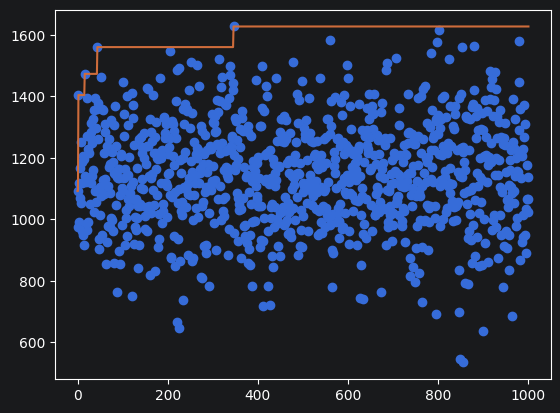

Najlepsze rozwiązanie: [ True False False False False  True  True  True  True  True  True  True
  True False False  True  True  True  True  True False False  True  True
 False  True False  True False  True  True  True  True False False False
 False False  True  True  True  True False False False  True  True False
 False  True]
Przedmioty: [ 0  5  6  7  8  9 10 11 12 15 16 17 18 19 22 23 25 27 29 30 31 32 38 39
 40 41 45 46 49]
Suma wag: 1115
Suma wartosci: 1627


In [13]:
sol_random_search = search_random(w, v, W, 1000)

print('Najlepsze rozwiązanie:', sol_random_search[0])
print('Przedmioty:', np.arange(num)[sol_random_search[0]])
print('Suma wag:', sol_random_search[1])
print('Suma wartosci:', sol_random_search[2])

## Greedy search - procedura optymalizacji zachłannej

Problemem w powyższym podejściu jest fakt, że kolejne rozwiązania nie korzystają z uzyskanej już wiedzy o najlepszych do tej pory rozwiązaniach. Zatem inna prosta heurytyka polega na wystartowaniu z losowego rozwiązania, a następnie modyfikowaniu go poprzez losowe dodawanie przedmiotu do plecaka. Jeśli zmiana (po ewentualnej naprawie) wprowadza poprawę, pozostajemy przy takim rozwiązaniu, jeśli następuje pogorszenie, odrzucamy takie rozwiązanie i ponawiamy próbę.

Taka procedura jest przykładem optymalizacji zachłannej.

In [14]:
def search_greedy_improvement(w, v, W, iters):
	best_sol, best_W, best_V = get_random_solution(w, v, W)
	v_all = [best_V]
	v_best = [best_V]
	num = w.shape[0]
	for i in range(iters):
		sol = best_sol.copy()
		#set random 0 bit to 1
		indx = np.random.randint(num)
		while sol[indx % num] == True:
			indx = indx + 1
		sol[indx % num] = True
		#correct if needed
		if w[sol].sum() > W:
			correct_solution(w, v, W, sol)
		_V = v[sol].sum()
		_W = w[sol].sum()
		if best_V < _V:
			best_sol, best_W, best_V = sol.copy(), _W, _V
		v_all.append(_V)
		v_best.append(best_V)
	plt.figure()
	plt.plot(v_all)
	plt.plot(v_best)
	plt.show()
	return best_sol, best_W, best_V, v_all, v_best

__Przykładowe uruchomienie:__

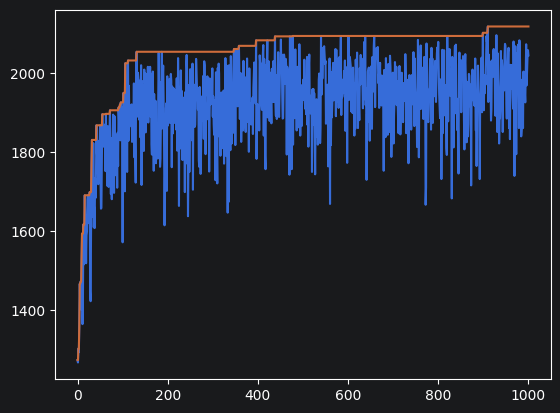

Najlepsze rozwiązanie: [ True  True False  True  True  True  True  True  True  True  True  True
  True  True  True False False  True False  True  True False False  True
 False False  True  True False  True  True False  True False  True False
 False False False  True  True  True False  True  True  True  True False
  True  True]
Przedmioty: [ 0  1  3  4  5  6  7  8  9 10 11 12 13 14 17 19 20 23 26 27 29 30 32 34
 39 40 41 43 44 45 46 48 49]
Suma wag: 1139
Suma wartosci: 2118


In [15]:
sol_greedy = search_greedy_improvement(w, v, W, 1000)

print('Najlepsze rozwiązanie:', sol_greedy[0])
print('Przedmioty:', np.arange(num)[sol_greedy[0]])
print('Suma wag:', sol_greedy[1])
print('Suma wartosci:', sol_greedy[2])

## Dwie inne proste heurystyki

### Najpierw najbardziej wartościowe

Jak dobre rozwiązanie dostaniemy, jeśli do plecaka pakować będziemy najpierw najbardziej wartościowe przedmioty (o ile się zmieszczą)? Pomysł ten jest zaimplementowany w poniższej funkcji.

In [16]:
#Pakuje najpierw najbardziej wartościowe przedmioty
def get_value_first(w, v, W):
	ii = np.argsort(-v)
	num = w.shape[0]
	sol = np.repeat(False, num)
	_W = 0
	for i in range(num):
		if _W + w[ii[i]] <= W:
			sol[ii[i]] = True
			_W = _W + w[ii[i]]
	_V = v[sol].sum()
	return sol, _W, _V

__Przykładowe uruchomienie:__

In [17]:
sol_value_first = get_value_first(w, v, W)

print('Najlepsze rozwiązanie:', sol_value_first[0])
print('Przedmioty:', np.arange(num)[sol_value_first[0]])
print('Suma wag:', sol_value_first[1])
print('Suma wartosci:', sol_value_first[2])

Najlepsze rozwiązanie: [ True  True False  True  True  True  True  True  True  True  True  True
  True False  True False False  True False  True  True False False  True
 False  True  True  True False  True  True False  True False  True False
 False False False  True False  True  True  True  True  True  True False
  True  True]
Przedmioty: [ 0  1  3  4  5  6  7  8  9 10 11 12 14 17 19 20 23 25 26 27 29 30 32 34
 39 41 42 43 44 45 46 48 49]
Suma wag: 1137
Suma wartosci: 2161


### Najpierw te o najlepszym stosunku wartości do wagi

Inny pomysł to pakowanie najpierw przedmiotów o najlepszym stosunku wartości do wagi.

In [18]:
def get_ratio_first(w, v, W):
	ii = np.argsort(-v / w)  #stosunek wartosci do wagi
	num = w.shape[0]
	sol = np.repeat(False, num)
	_W = 0
	for i in range(num):
		if _W + w[ii[i]] <= W:
			sol[ii[i]] = True
			_W = _W + w[ii[i]]
	_V = v[sol].sum()
	return sol, _W, _V

__Przykładowe uruchomienie:__

In [19]:
sol_ratio_first = get_ratio_first(w, v, W)

print('Najlepsze rozwiązanie:', sol_ratio_first[0])
print('Przedmioty:', np.arange(num)[sol_ratio_first[0]])
print('Suma wag:', sol_ratio_first[1])
print('Suma wartosci:', sol_ratio_first[2])

Najlepsze rozwiązanie: [ True  True False  True  True  True  True  True  True  True  True  True
  True False  True False False  True False  True  True False False  True
 False  True  True  True False  True  True False  True False  True False
 False False False  True  True  True  True False  True  True  True False
  True  True]
Przedmioty: [ 0  1  3  4  5  6  7  8  9 10 11 12 14 17 19 20 23 25 26 27 29 30 32 34
 39 40 41 42 44 45 46 48 49]
Suma wag: 1119
Suma wartosci: 2153


## Zadanie 2

Opracowane być mogą inne procedury naprawcze. Przykładowo, dla rozwiązania niedopuszczalengo, zamiast zmieniać losowe bity True na False, jak w funkcji `correct_solution`, można usuwać najpierw te przedmioty, które mają najgorszy stosunek wartości do wagi. Zaimplementuj taką procedurę.

Porównaj jej działanie z funkcją `correct_solution` w metodach RandomSearch oraz GreedySearch. Przedstaw uśrednione wyniki (co najmniej 10 uruchomień) i wnioski.

TWÓJ PROGRAM:

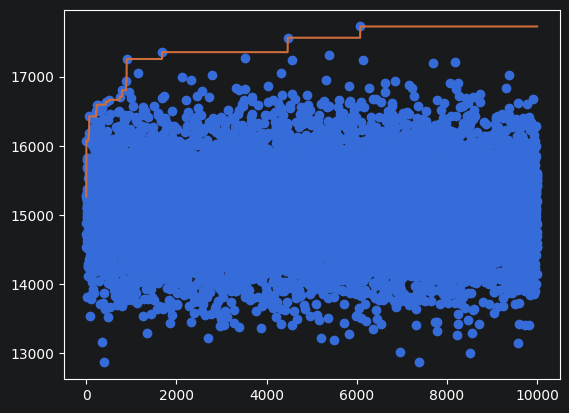

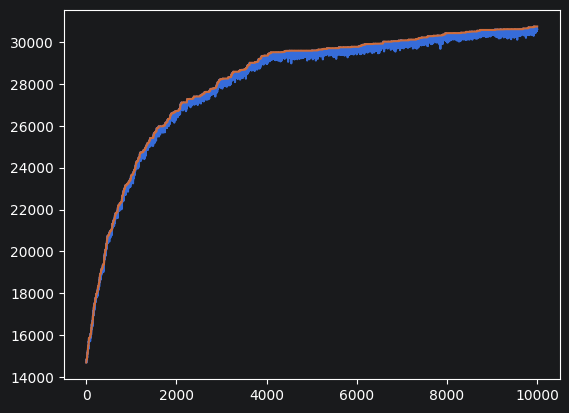

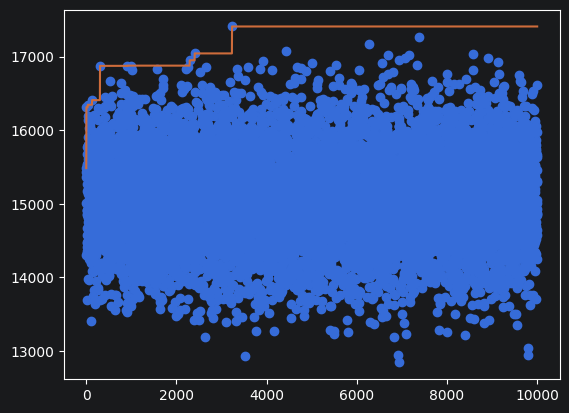

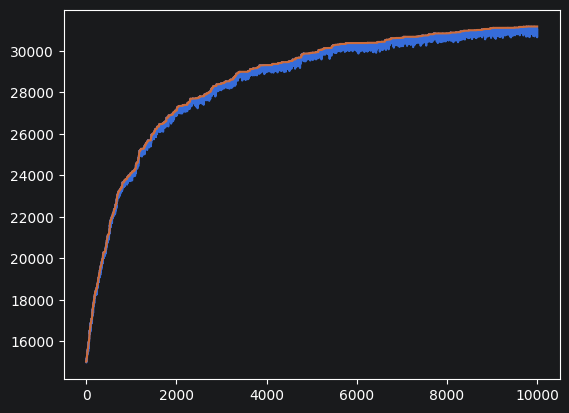

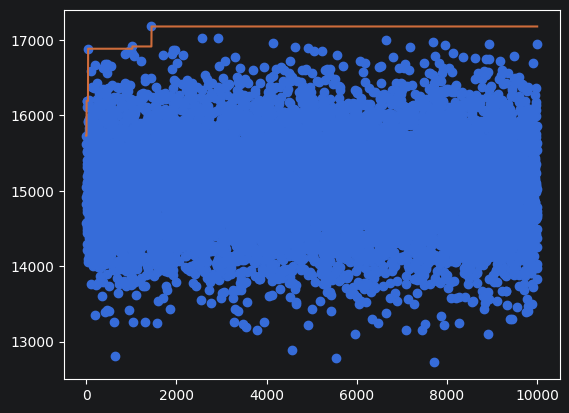

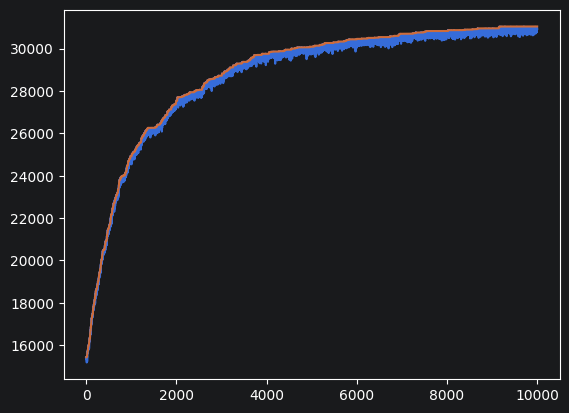

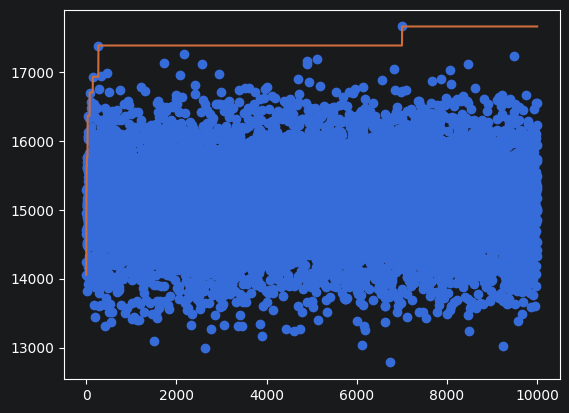

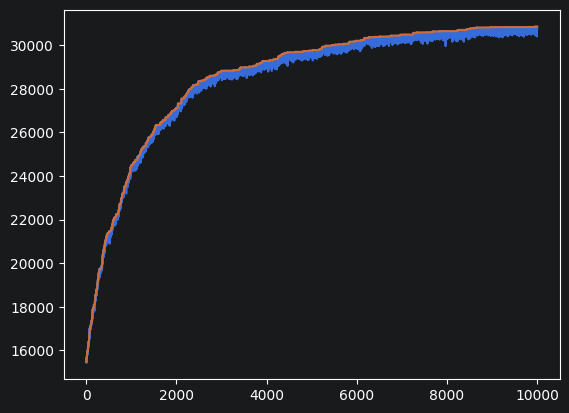

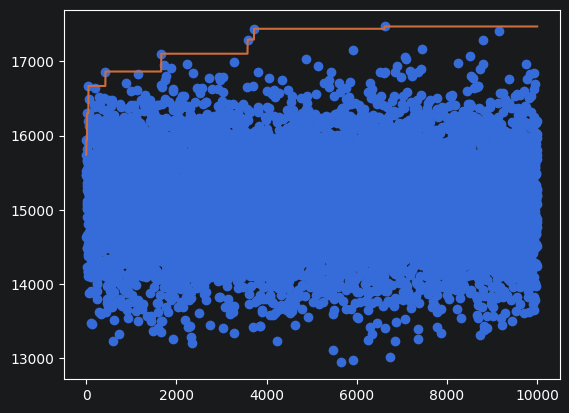

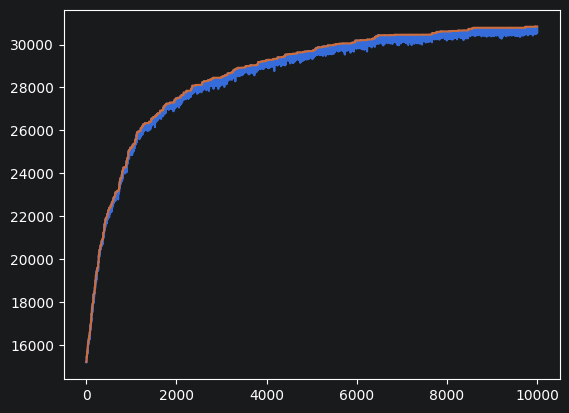

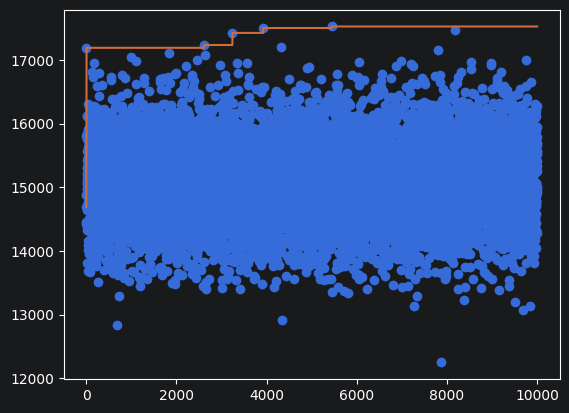

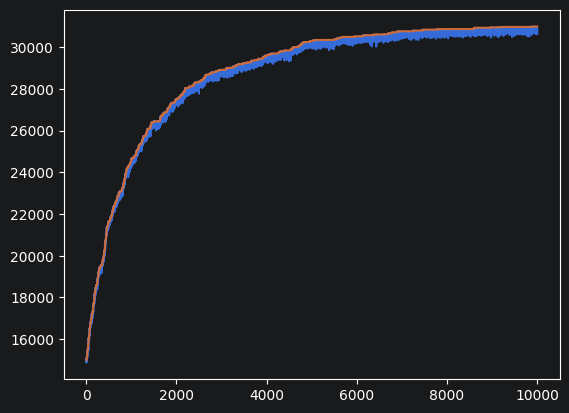

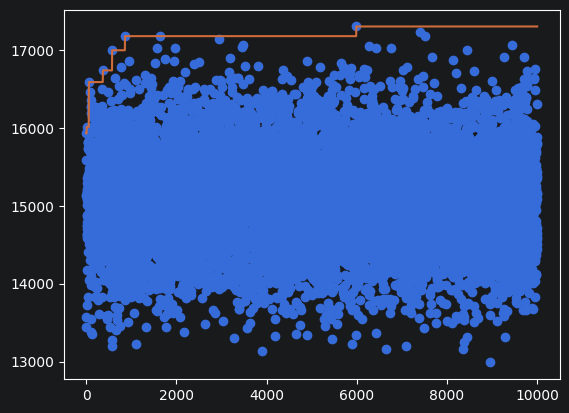

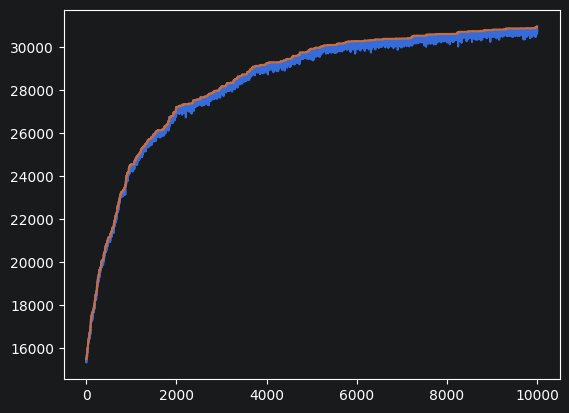

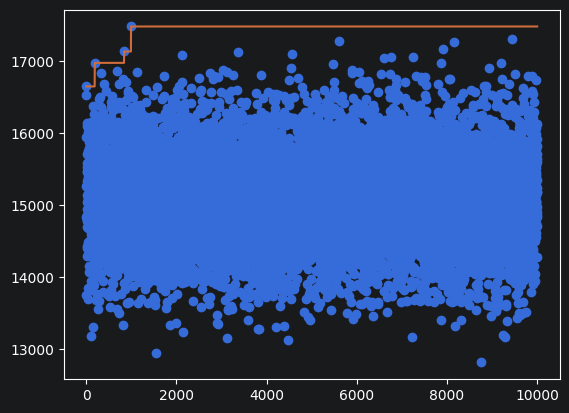

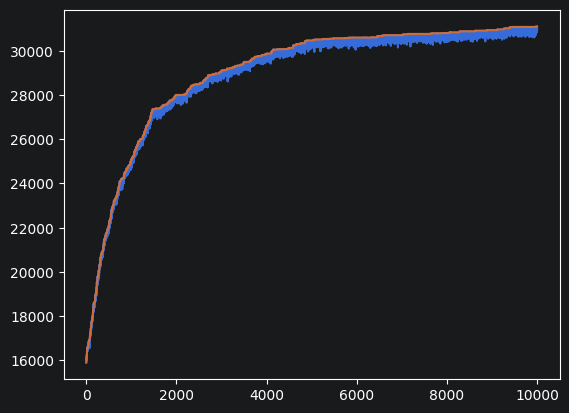

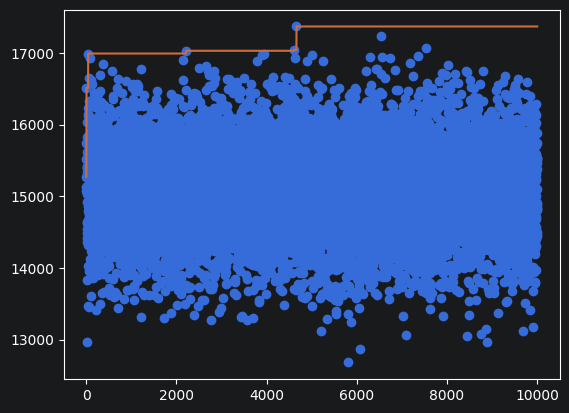

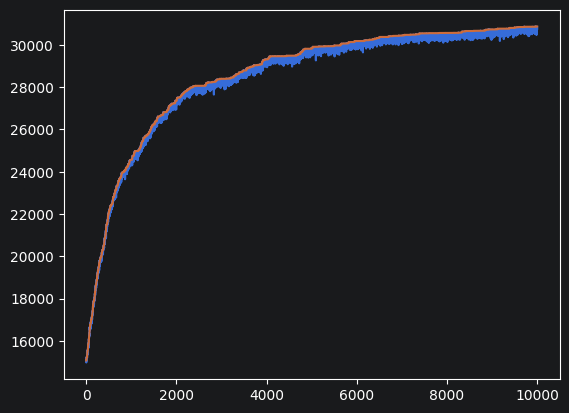

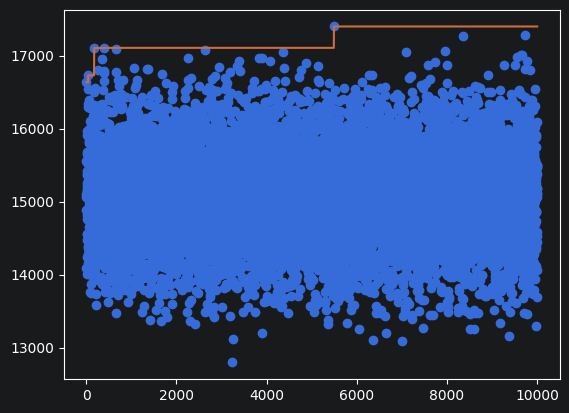

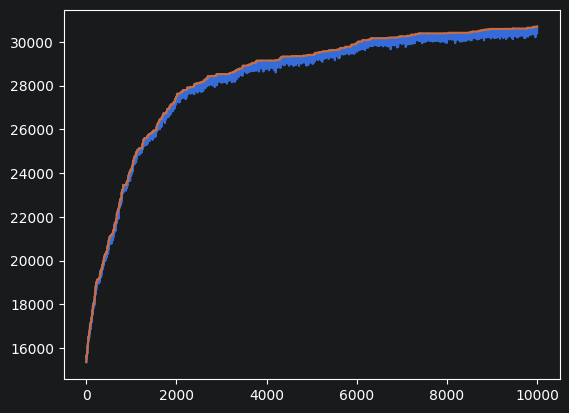

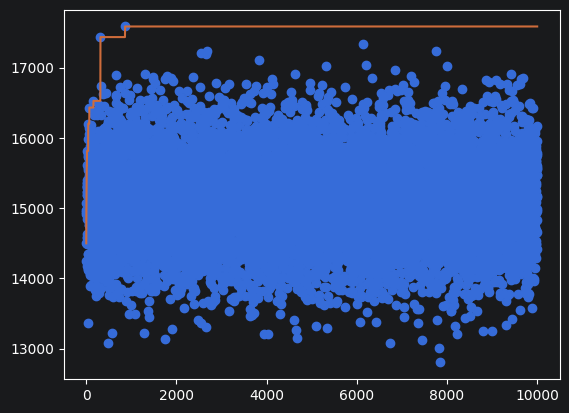

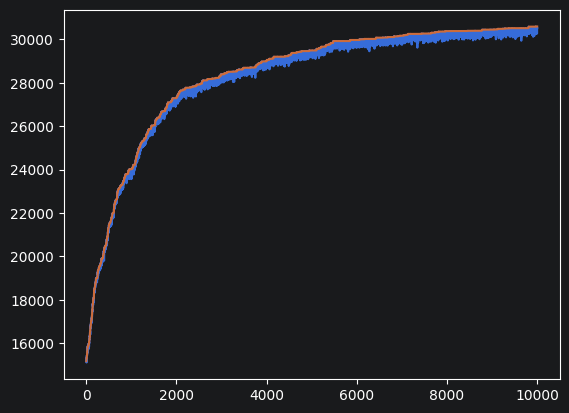

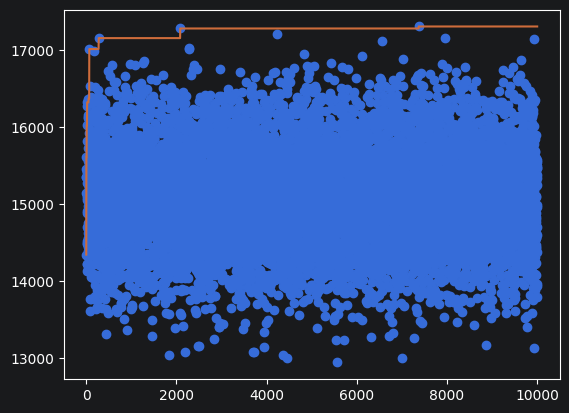

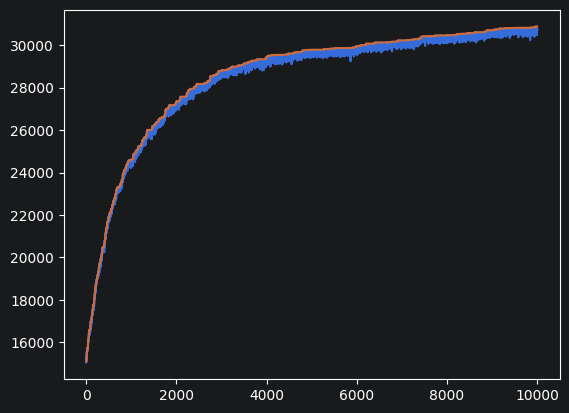

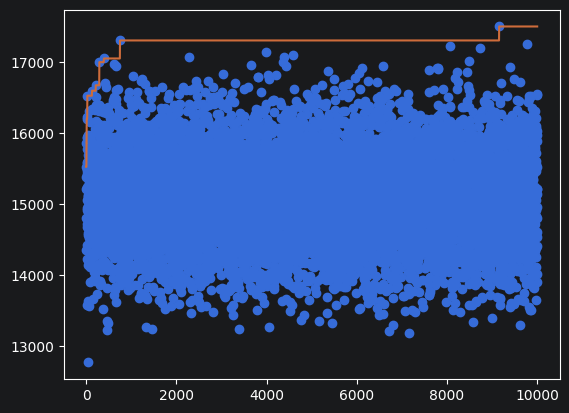

In [ ]:
# Funkcja naprawiająca rozwiązanie na podstawie stosunku wartości do wagi
def correct_solution_ratio(w, v, W, sol):
	# Dopóki waga przekracza limit
	while w[sol].sum() > W:
		# Pobranie indeksów wybranych przedmiotów
		selected = np.where(sol)[0]

		# Obliczenie stosunku wartości do wagi
		ratios = v[selected] / w[selected]

		# Znalezienie najgorszego przedmiotu
		worst = selected[np.argmin(ratios)]

		# Usunięcie najgorszego przedmiotu
		sol[worst] = False


# Funkcja generująca losowe rozwiązanie
def get_random_solution_ratio(w, v, W):
	# Pobranie liczby przedmiotów
	num = w.shape[0]

	# Wygenerowanie losowego rozwiązania
	sol = np.random.randint(0, 2, size=num, dtype=bool)

	# Naprawa rozwiązania jeśli przekracza wagę
	if w[sol].sum() > W:
		correct_solution_ratio(w, v, W, sol)

	# Zwrócenie rozwiązania, wagi i wartości
	return sol, w[sol].sum(), v[sol].sum()


# Funkcja realizująca Random Search
def search_random_ratio(w, v, W, iters):
	# Utworzenie początkowego najlepszego rozwiązania
	best_sol, best_W, best_V = get_random_solution_ratio(w, v, W)

	# Wykonanie zadanej liczby iteracji
	for i in range(iters):
		# Wygenerowanie nowego rozwiązania
		sol, _W, _V = get_random_solution_ratio(w, v, W)

		# Sprawdzenie, czy nowe rozwiązanie jest lepsze
		if _V > best_V:
			best_sol = sol.copy()
			best_W = _W
			best_V = _V

	# Zwrócenie najlepszego rozwiązania
	return best_sol, best_W, best_V


# Funkcja realizująca Greedy Search
def search_greedy_ratio(w, v, W, iters):
	# Utworzenie początkowego najlepszego rozwiązania
	best_sol, best_W, best_V = get_random_solution_ratio(w, v, W)

	# Pobranie liczby przedmiotów
	num = w.shape[0]

	for i in range(iters):
		# Skopiowanie najlepszego rozwiązania
		sol = best_sol.copy()

		# Wylosowanie indeksu
		indx = np.random.randint(num)

		# Szukanie wolnego miejsca
		while sol[indx % num] == True:
			indx += 1

		# Dodanie nowego przedmiotu
		sol[indx % num] = True

		# Naprawa rozwiązania, jeśli przekracza wagę
		if w[sol].sum() > W:
			correct_solution_ratio(w, v, W, sol)

		# Obliczenie wartości i wagi
		_V = v[sol].sum()
		_W = w[sol].sum()

		# Sprawdzenie, czy rozwiązanie jest lepsze
		if _V > best_V:
			best_sol = sol.copy()
			best_W = _W
			best_V = _V

	# Najlepsze rozwiązanie
	return best_sol, best_W, best_V


# Liczba uruchomień algorytmów
runs = 100

# Liczba iteracji
iters = 10000

# Listy wyników dla Random Search
random_old = []
random_new = []

# Listy wyników dla Greedy Search
greedy_old = []
greedy_new = []

for i in range(runs):
	# Uruchomienie starego Random Search
	s1 = search_random(w, v, W, iters)
	random_old.append(s1[2])

	# Uruchomienie nowego Random Search
	s2 = search_random_ratio(w, v, W, iters)
	random_new.append(s2[2])

	# Uruchomienie starego Greedy Search
	s3 = search_greedy_improvement(w, v, W, iters)
	greedy_old.append(s3[2])

	# Uruchomienie nowego Greedy Search
	s4 = search_greedy_ratio(w, v, W, iters)
	greedy_new.append(s4[2])

print("RANDOM SEARCH - stara naprawa:", np.mean(random_old))
print("RANDOM SEARCH - ratio naprawa:", np.mean(random_new))

print("GREEDY SEARCH - stara naprawa:", np.mean(greedy_old))
print("GREEDY SEARCH - ratio naprawa:", np.mean(greedy_new))

TWOJE WYNIKI i WNIOSKI:

Procedura usuwająca przedmioty o najgorszym stosunku wartości do wagi daje zwykle lepsze wyniki.
RandomSearch poprawił średnią wartość rozwiązania.
GreedySearch również działał lepiej przy naprawie opartej o ratio.
Nowa metoda zachowuje bardziej wartościowe przedmioty w plecaku.

## Zadanie 3

Dostosuj swoją implementację algorytmu genetycznego do problemu plecakowego.

- Jakie wyniki można uzyskać z jego pomocą? Czy działa on zawsze lepiej niż inne heurystyki?

- Która procedura naprawcza działa lepiej w algorytmie genetycznym?

- Przedstaw wnioski na podstawie uśrednionych wyników dla problemów plecakowych o rozmiarze 50, 100, 300.

- Problemy plecakowe i najlepsze znalezione rozwiązania zapisz do plików.

UWAGA! Po wygenerowaniu problemu plecakowego, przed uruchomieniem algorytmu genetycznego (lub innego) wywołaj:

`np.random.seed(int(time.time()))`

tak by problem plecakowy generował się ten sam, ale algorytmy miały szansę na nowy przebieg.

TWÓJ PROGRAM:

Problem: 50
Random Search: 1311.48
Greedy Search: 1352.28
Genetic Algorithm: 1370.94

Problem: 100
Random Search: 2646.7
Greedy Search: 2814.9
Genetic Algorithm: 2945.32

Problem: 300
Random Search: 8038.34
Greedy Search: 9374.86
Genetic Algorithm: 9547.88

Problem: 500
Random Search: 12840.24
Greedy Search: 16158.52
Genetic Algorithm: 15314.9

Problem: 1000
Random Search: 24422.04
Greedy Search: 32041.34
Genetic Algorithm: 28384.08



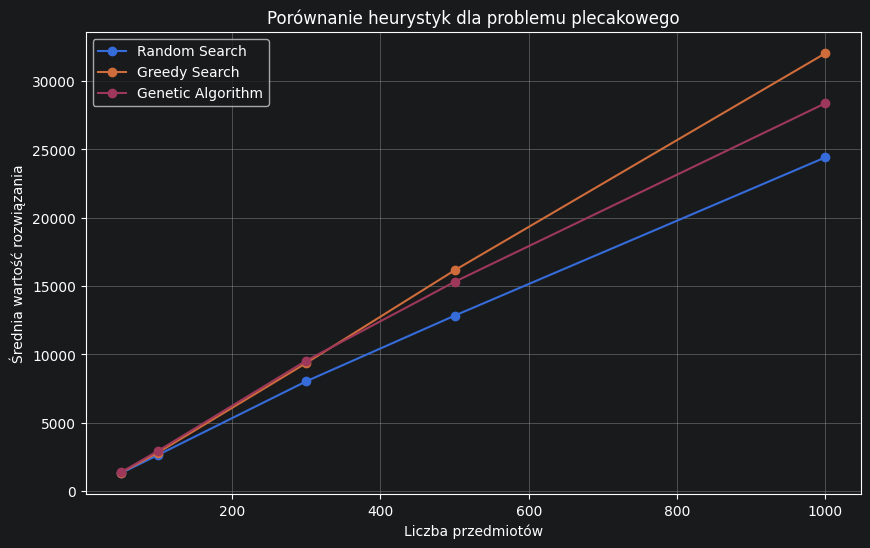

In [24]:
import time


# Funkcja generująca problem
def generate_problem(num, scale=100):
	# Losowanie wag
	w = np.random.randint(1, scale, num)

	# Losowanie wartości
	v = np.random.randint(1, scale, num)

	# Ustawienie pojemności plecaka
	W = int(w.sum() * 0.3)

	return w, v, W


# Funkcja naprawiająca rozwiązanie
def correct_solution_ratio(w, v, W, sol):
	# Dopóki rozwiązanie przekracza limit
	while w[sol].sum() > W:
		# Pobranie wybranych przedmiotów
		selected = np.where(sol)[0]

		# Obliczenie stosunku wartości do wagi
		ratios = v[selected] / w[selected]

		# Znalezienie najgorszego przedmiotu
		worst = selected[np.argmin(ratios)]

		# Usunięcie przedmiotu
		sol[worst] = False


# Funkcja obliczająca fitness
def fitness(w, v, W, sol):
	# Naprawa rozwiązania
	if w[sol].sum() > W:
		correct_solution_ratio(w, v, W, sol)

	# Zwrócenie wartości rozwiązania
	return v[sol].sum()


# Funkcja tworząca populację
def generate_population(pop_size, num):
	# Generowanie losowej populacji
	return np.random.randint(0, 2, size=(pop_size, num), dtype=bool)


# Funkcja krzyżowania
def crossover(parent1, parent2):
	# Wylosowanie punktu podziału
	point = np.random.randint(1, len(parent1))

	# Utworzenie dziecka
	child = np.concatenate((parent1[:point], parent2[point:]))

	return child


# Funkcja mutacji
def mutate(sol, prob=0.02):
	# Mutacja każdego genu
	for i in range(len(sol)):
		if np.random.rand() < prob:
			sol[i] = not sol[i]

	return sol


# Funkcja realizująca algorytm genetyczny
def genetic_algorithm(w, v, W, pop_size=50, generations=200):
	# Pobranie liczby przedmiotów
	num = len(w)

	# Utworzenie populacji
	population = generate_population(pop_size, num)

	# Najlepsze rozwiązanie
	best_sol = None
	best_val = 0
	best_weight = 0

	# Wykonanie kolejnych generacji
	for g in range(generations):
		# Obliczenie fitness dla populacji
		scores = []

		for sol in population:
			val = fitness(w, v, W, sol)

			scores.append(val)

			# Aktualizacja najlepszego rozwiązania
			if val > best_val:
				best_sol = sol.copy()
				best_val = val
				best_weight = w[sol].sum()

		# Sortowanie populacji
		order = np.argsort(scores)[::-1]

		population = population[order]

		# Pobranie najlepszej połowy
		parents = population[:pop_size // 2]

		# Tworzenie nowej populacji
		new_population = []

		while len(new_population) < pop_size:
			# Losowanie rodziców
			p1 = parents[np.random.randint(len(parents))]
			p2 = parents[np.random.randint(len(parents))]

			# Krzyżowanie
			child = crossover(p1, p2)

			# Mutacja
			child = mutate(child)

			# Dodanie dziecka
			new_population.append(child)

		population = np.array(new_population)

	# Zwrócenie najlepszego rozwiązania
	return best_sol, best_weight, best_val


# Rozmiary problemów
sizes = [50, 100, 300, 500, 1000]

# Liczba uruchomień
runs = 50

# Liczba iteracji dla heurystyk
iters = 10000

# Listy średnich wyników
random_results = []
greedy_results = []
genetic_results = []

for size in sizes:
	# Generowanie tego samego problemu
	np.random.seed(0)

	w, v, W = generate_problem(size)

	# Ustawienie nowego ziarna dla algorytmów
	np.random.seed(int(time.time()))

	random_vals = []
	greedy_vals = []
	genetic_vals = []

	for i in range(runs):
		# Random Search
		s1 = search_random_ratio(w, v, W, iters)
		random_vals.append(s1[2])

		# Greedy Search
		s2 = search_greedy_ratio(w, v, W, iters)
		greedy_vals.append(s2[2])

		# Algorytm genetyczny
		s3 = genetic_algorithm(w, v, W)
		genetic_vals.append(s3[2])

	# Obliczenie średnich
	random_mean = np.mean(random_vals)
	greedy_mean = np.mean(greedy_vals)
	genetic_mean = np.mean(genetic_vals)

	# Dodanie wyników do list
	random_results.append(random_mean)
	greedy_results.append(greedy_mean)
	genetic_results.append(genetic_mean)

	# Wyświetlenie wyników
	print("Problem:", size)

	print("Random Search:", random_mean)
	print("Greedy Search:", greedy_mean)
	print("Genetic Algorithm:", genetic_mean)

	print()

	np.savetxt(f"problem_{size}_weights.txt", w, fmt='%d')
	np.savetxt(f"problem_{size}_values.txt", v, fmt='%d')

	# Zapis najlepszego rozwiązania genetycznego
	best_sol, _, _ = genetic_algorithm(w, v, W)

	np.savetxt(f"solution_{size}.txt", best_sol.astype(int), fmt='%d')

plt.figure(figsize=(10, 6))

plt.plot(sizes, random_results, marker='o', label='Random Search')
plt.plot(sizes, greedy_results, marker='o', label='Greedy Search')
plt.plot(sizes, genetic_results, marker='o', label='Genetic Algorithm')

plt.title("Porównanie heurystyk dla problemu plecakowego")
plt.xlabel("Liczba przedmiotów")
plt.ylabel("Średnia wartość rozwiązania")

plt.legend()
plt.grid(True)

plt.show()

TWOJE WYNIKI i WNIOSKI:

Random Search osiągał najsłabsze wyniki dla wszystkich rozmiarów problemu
Greedy Search oraz Genetic Algorithm uzyskiwały znacznie lepsze rezultaty
Dla problemów o rozmiarze 50, 100 i 300 najlepsze wyniki osiągał algorytm genetyczny
Dla problemów o rozmiarze 500 i 1000 lepsze wyniki osiągał Greedy Search
Wraz ze wzrostem liczby przedmiotów rosła wartość uzyskanych rozwiązań


Algorytm genetyczny skutecznie rozwiązuje problem plecakowy, ale nie zawsze działa lepiej niż heurystyki zachłanne
Greedy Search okazał się bardziej efektywny dla dużych problemów
Random Search dawał zdecydowanie gorsze wyniki
Procedura naprawcza oparta o stosunek wartości do wagi działa poprawnie i stabilnie
Wyniki algorytmu genetycznego zależą od parametrów populacji i liczby generacji

&copy; Cracow University of Technology